In [ ]:
# the import
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# reading the file
car_df = pd.read_csv('/content/car data.csv')

In [ ]:
car_df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
car_df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
#check the dulicates
car_df.drop_duplicates()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
car_df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
# seperate the target from the other features
x = car_df.drop('Selling_Price' , axis=1)
y = car_df['Selling_Price']

In [ ]:
# checking and removing the ouliers wiht the interquartile range
for col in car_df.select_dtypes(include=np.number).columns :
  Q1_car = car_df[col].quantile(.25)
  Q3_car = car_df[col].quantile(.75)
  IQR_car = Q3_car - Q1_car
  lower_car = Q1_car - 1.5 * IQR_car
  Upper_car = Q3_car + 1.5 * IQR_car
  car_df[col] = car_df[col].clip(lower_car,Upper_car)


In [ ]:
car_df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.0
mean,2013.667774,4.272359,7.076578,34426.617940,0.0
std,2.768139,3.749446,6.162499,23726.441467,0.0
min,2006.000000,0.100000,0.320000,500.000000,0.0
25%,2012.000000,0.900000,1.200000,15000.000000,0.0
50%,2014.000000,3.600000,6.400000,32000.000000,0.0
75%,2016.000000,6.000000,9.900000,48767.000000,0.0
max,2018.000000,13.650000,22.950000,99417.500000,0.0


In [ ]:
car_df = car_df.drop('Car_Name', axis=1)

In [ ]:
# the encoding step
Label_E = LabelEncoder()
for col in car_df.select_dtypes(include = 'object').columns:
  car_df[col] = Label_E.fit_transform(car_df[col])


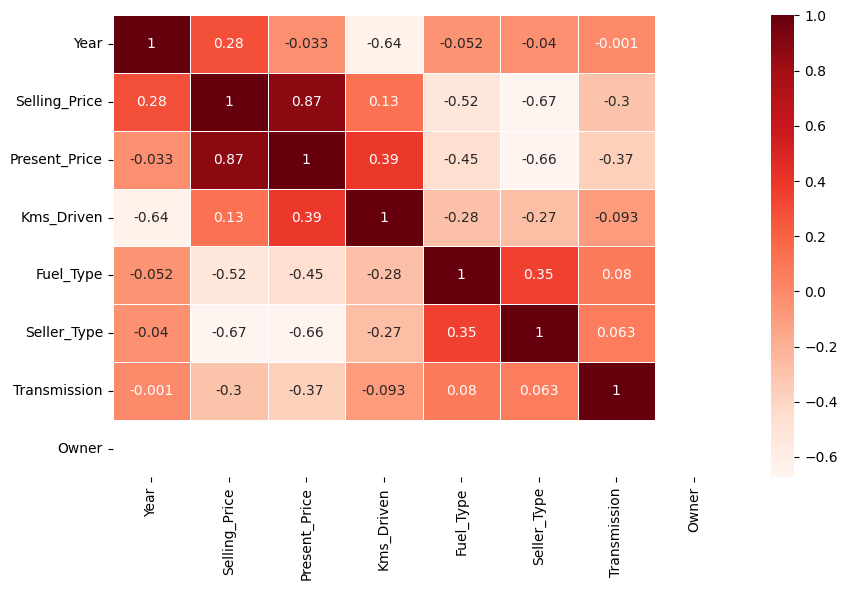

In [ ]:
# check for the corrrelation
corr = car_df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='Reds', linewidths=0.5 )
plt.show()

In [ ]:
# splitting the data into test and train -> there is no high correlation between the columns
X_train_car, X_test_car, y_train_car, y_test_car = train_test_split (x,y, test_size= .2 , random_state = 20)

In [ ]:
# scaling the data
X_train_car = X_train_car.select_dtypes(include=['int64', 'float64'])
X_test_car = X_test_car.select_dtypes(include=['int64', 'float64'])
car_scaler = StandardScaler()
X_train_car = car_scaler.fit_transform(X_train_car)
X_test_car = car_scaler.transform(X_test_car)

In [ ]:
model = LinearRegression()
model.fit(X_train_car, y_train_car)


LinearRegression()

In [ ]:
y_train_pred = model.predict(X_train_car)


In [ ]:
# check the accuracy of the train
print("Train MSE:", mean_squared_error(y_train_car, y_train_pred))
print("Train R2 Score:", r2_score(y_train_car, y_train_pred))

Train MSE: 4.045230435190285
Train R2 Score: 0.8427682067562764


In [ ]:
y_pred = model.predict(X_test_car)


In [ ]:
# check the accuracy of the test
# the train and test accuracy is so close to each other -> there is no overfitting
print("Test MSE:", mean_squared_error(y_test_car, y_pred))
print("Test R2 Score:", r2_score(y_test_car, y_pred))

Test MSE: 2.917338542745878
Test R2 Score: 0.8859809724372947
